# Multi-LLM vs. Multi-Human Grading Analysis — Biomaterials

**Question that frames everything:** *Does an LLM behave like an additional qualified human grader?*

We have per-question grades from **three independent human graders** and **seven LLMs**, each run **three times** on **five student submissions** (5 questions each, 2 points/question, 10 total).

Rather than comparing each LLM to a single human, we treat the three humans as the reference standard, first quantify how much the humans agree (the realistic **ceiling**), build a **consensus** human grade, and then ask whether each LLM falls *within human variability*.

**Notebook roadmap**
1. Load & tidy the data
2. Human–human agreement (upper bound): ICC, Krippendorff's α, weighted κ, Kendall's W
3. Consensus reference grade (mean / median)
4. Every LLM vs. consensus: MAE, RMSE, Pearson, Spearman, R², bias, error SD
5. LLM as a *fourth grader* (ICC with the LLM added)
6. LLM↔Human vs. Human↔Human agreement
7. Per-question analysis (easy / hard / interesting-failure)
8. Run-to-run LLM self-consistency *(added)*
9. Statistical significance (Wilcoxon paired tests)
10. Visualizations
11. Overall ranking & composite score


## 0. Setup

In [1]:
import ast, json, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats
warnings.filterwarnings("ignore")

# optional stats libs
import pingouin as pg
import krippendorff

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "axes.grid": True, "grid.alpha": .25,
})

# consistent, colour-blind-safe model palette
MODEL_COLORS = {}
def short_model(m):
    return (m.replace("global.anthropic.", "")
             .replace("-v1:0", "").replace("-v1", "")
             .replace("claude-", "claude-"))
DATA_CSV = "grading_results/grading_results_with_human_score.csv"
print("setup ok")

setup ok


## 1. Load & tidy the data

Each row is one *(student × model × run)* grading. The two nested columns we unpack:

* `feedback_by_question` — the **LLM's** per-question `score` / `max_points`
* `human_grades_by_question` — the **three graders'** per-question scores

We build two tidy long tables:

* `human_long` — one row per *(student, question, grader)*  → 5·5·3 = 75 rows
* `llm_long`  — one row per *(student, question, model, run)* → 5·5·7·3 = 525 rows

The natural **unit of analysis** is the *question instance* (`pdf_id`,`question`) — 25 of them — which gives far more statistical power (25 points) than the 5 student totals.

In [2]:
df = pd.read_csv(DATA_CSV)
df["model_s"] = df["model"].map(short_model)
MODELS = sorted(df["model_s"].unique())
QS = [1,2,3,4,5]

# stable colours
cmap = plt.get_cmap("tab10")
for i,m in enumerate(MODELS):
    MODEL_COLORS[m] = cmap(i % 10)

# ---- LLM long ----
llm_rows = []
for _,r in df.iterrows():
    fb = ast.literal_eval(r["feedback_by_question"])
    for q in QS:
        llm_rows.append(dict(pdf_id=r["pdf_id"], student=r["student_name"],
                             model=r["model_s"], run=int(r["run"]), question=q,
                             score=float(fb[str(q)]["score"]),
                             max_points=float(fb[str(q)]["max_points"])))
llm_long = pd.DataFrame(llm_rows)

# ---- Human long (grades are identical across model/run; take first row per pdf) ----
hum_rows = []
for pid, g in df.groupby("pdf_id"):
    hg = ast.literal_eval(g.iloc[0]["human_grades_by_question"])
    for q in QS:
        for gr in ["grader_1","grader_2","grader_3"]:
            hum_rows.append(dict(pdf_id=pid, student=g.iloc[0]["student_name"],
                                 question=q, grader=gr, score=float(hg[str(q)][gr])))
human_long = pd.DataFrame(hum_rows)

print("llm_long", llm_long.shape, "| human_long", human_long.shape)
print("models:", MODELS)
display(llm_long.head()); display(human_long.head())

llm_long (525, 7) | human_long (75, 5)
models: ['claude-haiku-4-5-20251001', 'claude-opus-4-6', 'claude-sonnet-4-6', 'gemini-2.5-flash', 'gemini-2.5-pro', 'gpt-4o', 'gpt-5']


,pdf_id,student,model,run,question,score,max_points
0,1,Dinesh,gpt-5,1,1,1.750,2.000
1,1,Dinesh,gpt-5,1,2,0.500,2.000
2,1,Dinesh,gpt-5,1,3,1.000,2.000
3,1,Dinesh,gpt-5,1,4,0.500,2.000
4,1,Dinesh,gpt-5,1,5,1.500,2.000


,pdf_id,student,question,grader,score
0,1,Dinesh,1,grader_1,2.000
1,1,Dinesh,1,grader_2,2.000
2,1,Dinesh,1,grader_3,2.000
3,1,Dinesh,2,grader_1,1.500
4,1,Dinesh,2,grader_2,1.500


**Sanity checks** — per-question max is 2.0 for everyone, LLM per-run totals reconstruct `total_score`, and human per-question sums reconstruct each grader's total.

In [3]:
# question-level pivots
# human: wide matrix units(25) x 3 graders
hum_wide = human_long.pivot_table(index=["pdf_id","question"], columns="grader", values="score")
hum_wide.columns = ["H1","H2","H3"]

# llm run-averaged: units(25) x model  (avg over 3 runs)
llm_q = (llm_long.groupby(["pdf_id","question","model"])["score"].mean()
         .reset_index())
llm_wide = llm_q.pivot_table(index=["pdf_id","question"], columns="model", values="score")

assert (llm_long["max_points"]==2.0).all()
print("units:", len(hum_wide), " | human wide", hum_wide.shape, " | llm wide", llm_wide.shape)
display(hum_wide.head())
display(llm_wide.round(2).head())

units: 25  | human wide (25, 3)  | llm wide (25, 7)


H1    H2    H3
pdf_id question                  
1      1        2.000 2.000 2.000
       2        1.500 1.500 2.000
       3        1.500 1.500 1.500
       4        2.000 2.000 2.000
       5        2.000 2.000 2.000

model            claude-haiku-4-5-20251001  claude-opus-4-6  \
pdf_id question                                               
1      1                             1.700            1.500   
       2                             1.200            1.000   
       3                             1.530            1.000   
       4                             1.300            1.000   
       5                             1.530            1.500   

model            claude-sonnet-4-6  gemini-2.5-flash  gemini-2.5-pro  gpt-4o  \
pdf_id question                                                                
1      1                     1.530             1.920           1.670   1.500   
       2                     1.000             0.330           0.500   1.000   
       3                     1.400             1.000           0.830   1.170   
       4                     1.070             1.000           0.500   0.830   
       5                     1.530             1.580           1.920   1.170   

model            gpt-5  
pdf_id question         
1      1         1.650  
       2         0.530  
       3         1.000  
       4         0.830  
       5         1.600

## 1b. Overview — how the graders differ at a glance

In [4]:
tot_h = df.groupby("pdf_id")[["grader_1_total_score","grader_2_total_score","grader_3_total_score"]].first()
tot_h.columns=["H1","H2","H3"]
tot_l = df.groupby(["pdf_id","model_s"])["total_score"].mean().unstack()
overview = tot_h.join(tot_l)
print("Per-student totals (out of 10) — humans then LLMs (run-averaged):")
display(overview.round(2))

print("\nGrand mean total score (out of 10):")
means = pd.concat([tot_h.mean().rename("mean"), tot_l.mean().rename("mean")]).sort_values()
display(means.to_frame().round(2))
print("Humans grade markedly higher than the LLMs on this rubric — an overall harshness/leniency gap we quantify as *bias* below.")

Per-student totals (out of 10) — humans then LLMs (run-averaged):


,H1,H2,H3,claude-haiku-4-5-20251001,claude-opus-4-6,claude-sonnet-4-6,gemini-2.5-flash,gemini-2.5-pro,gpt-4o,gpt-5
pdf_id,,,,,,,,,,
1,9.000,9.000,9.500,7.270,6.000,6.530,5.830,5.420,5.670,5.620
2,9.500,9.000,9.500,8.500,8.170,7.670,8.170,8.830,7.330,8.170
3,8.500,6.500,8.000,7.700,5.580,5.580,5.420,5.670,5.000,5.170
4,10.000,9.000,9.500,7.000,8.780,8.770,8.750,8.670,7.670,7.320
5,9.500,5.500,9.000,6.580,5.830,5.800,5.370,5.170,5.670,4.300



Grand mean total score (out of 10):


,mean
gpt-5,6.110
gpt-4o,6.270
gemini-2.5-flash,6.710
gemini-2.5-pro,6.750
claude-sonnet-4-6,6.870
claude-opus-4-6,6.870
claude-haiku-4-5-20251001,7.410
H2,7.800
H3,9.100
H1,9.300


Humans grade markedly higher than the LLMs on this rubric — an overall harshness/leniency gap we quantify as *bias* below.


## 2. Human–human agreement (the upper bound)

Before judging any LLM we measure how consistent the humans themselves are. If the three humans only agree at, say, ICC = 0.7, then demanding ICC = 0.95 from an LLM is unrealistic. **Human agreement is the ceiling.**

We compute, at the question-instance level (25 units × 3 raters):

* **ICC(2,1)** — two-way random, absolute-agreement, single rater (the relevant form when any one rater — human or LLM — must stand in for the truth) and **ICC(2,k)** for the reliability of their *average*.
* **Krippendorff's α** (interval) — robust reliability coefficient.
* **Quadratic-weighted Cohen's κ** — pairwise, treats the 0/0.5/…/2 grades as ordinal.
* **Kendall's W** — rank concordance.
* **Pairwise MAE** — average absolute disagreement, in raw points.

In [5]:
def icc_from_wide(wide, raters):
    # wide: units x raters. Returns pingouin ICC table (all forms).
    long = wide[raters].reset_index().melt(id_vars=[c for c in wide.index.names],
                                           value_vars=raters, var_name="rater", value_name="score")
    long["target"] = long[wide.index.names].astype(str).agg("-".join, axis=1)
    res = pg.intraclass_corr(data=long, targets="target", raters="rater", ratings="score").set_index("Type")
    return res

def get_icc(res, kind):
    # ICC(2,1)=two-way random, absolute agreement, single rater. pingouin labels
    # it "ICC(A,1)" (new) or "ICC2" (old); the average form is "ICC(A,k)"/"ICC2k".
    labels = {"single": ["ICC(A,1)","ICC2"], "avg": ["ICC(A,k)","ICC2k"]}[kind]
    for lab in labels:
        if lab in res.index: return float(res.loc[lab, "ICC"])
    raise KeyError(f"no ICC label found among {labels}")

icc_h = icc_from_wide(hum_wide, ["H1","H2","H3"])
display(icc_h[["ICC","pval"]])
icc21_h = get_icc(icc_h, "single"); icc2k_h = get_icc(icc_h, "avg")
print(f"Human ICC(2,1) single-rater = {icc21_h:.3f}   |   ICC(2,k) average = {icc2k_h:.3f}")

,ICC,pval
Type,,
ICC1,0.476,0.000
ICC2,0.504,0.000
ICC3,0.598,0.000
ICC1k,0.732,0.000
ICC2k,0.753,0.000
ICC3k,0.817,0.000


Human ICC(2,1) single-rater = 0.504   |   ICC(2,k) average = 0.753


In [6]:
# Krippendorff's alpha (interval): reliability_data = raters x units
def kripp_alpha(wide, raters):
    data = wide[raters].T.values  # raters x units
    return krippendorff.alpha(reliability_data=data, level_of_measurement="interval")
alpha_h = kripp_alpha(hum_wide, ["H1","H2","H3"])
print(f"Human Krippendorff's alpha (interval) = {alpha_h:.3f}")

# Quadratic weighted kappa (manual, ordinal categories)
def quadratic_weighted_kappa(a, b):
    cats = sorted(set(np.r_[a,b]))
    idx = {c:i for i,c in enumerate(cats)}; n=len(cats)
    O = np.zeros((n,n))
    for x,y in zip(a,b): O[idx[x],idx[y]] += 1
    W = np.array([[((i-j)**2)/((n-1)**2) for j in range(n)] for i in range(n)])
    act_a = O.sum(1); act_b = O.sum(0); N=O.sum()
    E = np.outer(act_a, act_b)/N
    num = (W*O).sum(); den = (W*E).sum()
    return 1 - num/den if den else np.nan

pairs = [("H1","H2"),("H1","H3"),("H2","H3")]
kappa_h = {f"{x}-{y}": quadratic_weighted_kappa(hum_wide[x].values, hum_wide[y].values) for x,y in pairs}
print("Pairwise quadratic-weighted kappa:", {k:round(v,3) for k,v in kappa_h.items()},
      " | mean =", round(np.mean(list(kappa_h.values())),3))

Human Krippendorff's alpha (interval) = 0.469
Pairwise quadratic-weighted kappa: {'H1-H2': np.float64(0.405), 'H1-H3': np.float64(0.599), 'H2-H3': np.float64(0.543)}  | mean = 0.516


In [7]:
# Kendall's W (concordance) via Friedman statistic
def kendalls_w(wide, raters):
    M = wide[raters].values            # units x raters
    n, k = M.shape                     # n items, k raters
    R = np.apply_along_axis(stats.rankdata, 0, M)  # rank items within each rater
    Rsum = R.sum(1)
    S = ((Rsum - Rsum.mean())**2).sum()
    # tie correction omitted-light; standard formula
    return 12*S/(k**2*(n**3-n))
W_h = kendalls_w(hum_wide, ["H1","H2","H3"])
print(f"Human Kendall's W = {W_h:.3f}")

# pairwise MAE among humans
def pairwise_mae(wide, raters):
    return {f"{x}-{y}": np.abs(wide[x]-wide[y]).mean() for x,y in itertools.combinations(raters,2)}
mae_hh = pairwise_mae(hum_wide, ["H1","H2","H3"])
print("Human-human pairwise MAE (points):", {k:round(v,3) for k,v in mae_hh.items()},
      " | mean =", round(np.mean(list(mae_hh.values())),3))
mean_hh_mae = np.mean(list(mae_hh.values()))

Human Kendall's W = 0.505
Human-human pairwise MAE (points): {'H1-H2': np.float64(0.3), 'H1-H3': np.float64(0.12), 'H2-H3': np.float64(0.26)}  | mean = 0.227


> **Read-out.** These four coefficients together define the *human ceiling*. The mean human–human MAE in particular is the single most intuitive benchmark: **any LLM whose error against the humans is on this order is effectively indistinguishable from a fourth human.** We reuse `mean_hh_mae` throughout.

## 3. Consensus reference grade

Rather than privileging one grader, we form a consensus per question instance:

* **Mean** — best for continuous marks (our default reference).
* **Median** — more robust if one grader is unusually harsh (grader H2 looks harsh above).

In [8]:
ref = pd.DataFrame(index=hum_wide.index)
ref["mean"]   = hum_wide[["H1","H2","H3"]].mean(1)
ref["median"] = hum_wide[["H1","H2","H3"]].median(1)
ref["std"]    = hum_wide[["H1","H2","H3"]].std(1, ddof=1)
print("Mean vs median reference agree closely (corr = %.3f); we use the MEAN consensus." %
      ref[["mean","median"]].corr().iloc[0,1])
display(ref.head())
CONSENSUS = ref["mean"]

Mean vs median reference agree closely (corr = 0.899); we use the MEAN consensus.


mean  median   std
pdf_id question                    
1      1        2.000   2.000 0.000
       2        1.667   1.500 0.289
       3        1.500   1.500 0.000
       4        2.000   2.000 0.000
       5        2.000   2.000 0.000

## 4. Every LLM vs. the consensus

For each model (run-averaged per question) against the mean consensus, over the 25 question instances:

| metric | meaning | good |
|---|---|---|
| **MAE** | mean absolute error | ↓ |
| **RMSE** | penalises large misses | ↓ |
| **Pearson r** | linear agreement | ↑ |
| **Spearman ρ** | ranking agreement | ↑ |
| **R²** | variance explained | ↑ |
| **Bias** | mean(LLM − human): + generous, − harsh | →0 |
| **Error SD** | consistency of the error | ↓ |

In [9]:
def metrics_vs_ref(pred, ref):
    err = pred - ref
    mae = np.abs(err).mean(); rmse = np.sqrt((err**2).mean())
    bias = err.mean(); sd = err.std(ddof=1)
    r = stats.pearsonr(pred, ref)[0] if pred.std()>0 else np.nan
    rho = stats.spearmanr(pred, ref)[0]
    ss_res = (err**2).sum(); ss_tot = ((ref-ref.mean())**2).sum()
    r2 = 1-ss_res/ss_tot if ss_tot else np.nan
    return dict(MAE=mae, RMSE=rmse, Pearson=r, Spearman=rho, R2=r2, Bias=bias, ErrSD=sd)

rows = {}
for m in MODELS:
    pred = llm_wide[m].reindex(CONSENSUS.index)
    rows[m] = metrics_vs_ref(pred.values, CONSENSUS.values)
llm_metrics = pd.DataFrame(rows).T
llm_metrics = llm_metrics.sort_values("MAE")
print("Question-level metrics vs. mean consensus (25 instances). Human-human mean MAE = %.3f (dashed benchmark).\n" % mean_hh_mae)
display(llm_metrics.style.format("{:.3f}")
        .background_gradient(subset=["MAE","RMSE","ErrSD"], cmap="Reds")
        .background_gradient(subset=["Pearson","Spearman","R2"], cmap="Greens"))

Question-level metrics vs. mean consensus (25 instances). Human-human mean MAE = 0.227 (dashed benchmark).



,MAE,RMSE,Pearson,Spearman,R2,Bias,ErrSD
claude-haiku-4-5-20251001,0.339,0.416,0.464,0.357,-0.892,-0.265,0.327
claude-opus-4-6,0.385,0.465,0.671,0.686,-1.362,-0.372,0.284
claude-sonnet-4-6,0.386,0.461,0.635,0.648,-1.323,-0.373,0.277
gemini-2.5-flash,0.419,0.554,0.690,0.722,-2.353,-0.405,0.385
gemini-2.5-pro,0.423,0.594,0.634,0.679,-2.858,-0.397,0.451
gpt-4o,0.507,0.558,0.616,0.656,-2.405,-0.493,0.266
gpt-5,0.544,0.663,0.590,0.617,-3.812,-0.524,0.415


**Bias sign** tells us the story of the harshness gap directly:

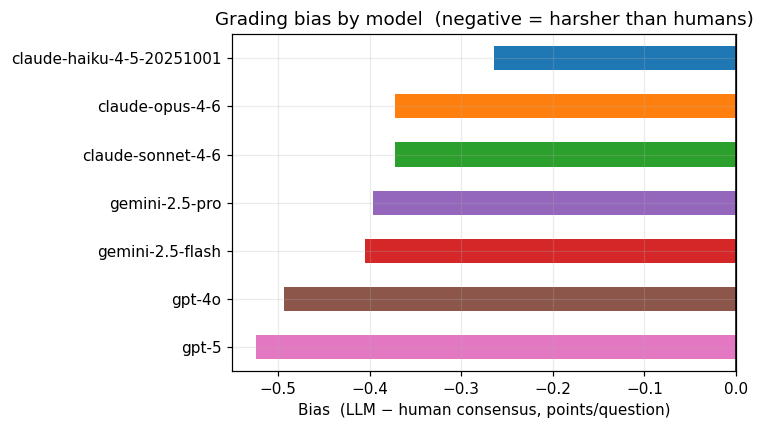

All/most models sit left of zero -> the LLMs are systematically HARSHER graders than the humans on this rubric.


In [10]:
ax = llm_metrics["Bias"].sort_values().plot.barh(
        color=[MODEL_COLORS[m] for m in llm_metrics["Bias"].sort_values().index], figsize=(7,4))
ax.axvline(0, color="k", lw=1)
ax.set_xlabel("Bias  (LLM − human consensus, points/question)")
ax.set_title("Grading bias by model  (negative = harsher than humans)")
plt.tight_layout(); plt.show()
print("All/most models sit left of zero -> the LLMs are systematically HARSHER graders than the humans on this rubric.")

## 5. Does the LLM behave like a *fourth grader*?

The strongest test in the doc: drop each LLM in as a fourth rater alongside H1/H2/H3 and recompute ICC over 25 units × 4 raters. **If ICC barely drops from the human-only value, the LLM is contributing reliability like another human examiner would.** We also report Krippendorff's α for the 4-rater panel.

In [11]:
rows=[]
for m in MODELS:
    w4 = hum_wide[["H1","H2","H3"]].copy()
    w4["LLM"] = llm_wide[m].reindex(w4.index)
    icc4 = icc_from_wide(w4, ["H1","H2","H3","LLM"])
    a4 = kripp_alpha(w4, ["H1","H2","H3","LLM"])
    rows.append(dict(model=m,
                     ICC21_with_LLM=get_icc(icc4, "single"),
                     ICC2k_with_LLM=get_icc(icc4, "avg"),
                     Kripp_alpha_with_LLM=a4))
icc_panel = pd.DataFrame(rows).set_index("model")
icc_panel["ICC21_drop_vs_human"] = icc_panel["ICC21_with_LLM"] - icc21_h
icc_panel = icc_panel.sort_values("ICC21_with_LLM", ascending=False)
print(f"Human-only ICC(2,1) = {icc21_h:.3f}, Krippendorff alpha = {alpha_h:.3f}\n")
display(icc_panel.style.format("{:.3f}")
        .background_gradient(subset=["ICC21_with_LLM","ICC2k_with_LLM"], cmap="Greens"))
print("A near-zero or positive 'ICC21_drop_vs_human' means adding that LLM preserves inter-rater reliability -> it acts like a qualified 4th grader.")

Human-only ICC(2,1) = 0.504, Krippendorff alpha = 0.469



,ICC21_with_LLM,ICC2k_with_LLM,Kripp_alpha_with_LLM,ICC21_drop_vs_human
model,,,,
gemini-2.5-flash,0.426,0.748,0.381,-0.077
claude-opus-4-6,0.425,0.748,0.376,-0.078
claude-sonnet-4-6,0.408,0.734,0.355,-0.096
gemini-2.5-pro,0.407,0.733,0.364,-0.097
claude-haiku-4-5-20251001,0.397,0.725,0.356,-0.107
gpt-5,0.347,0.680,0.281,-0.156
gpt-4o,0.342,0.676,0.265,-0.161


A near-zero or positive 'ICC21_drop_vs_human' means adding that LLM preserves inter-rater reliability -> it acts like a qualified 4th grader.


## 6. LLM↔Human vs. Human↔Human

The most intuitive practical argument: if a model's average disagreement with each human is comparable to how much the humans disagree *with each other*, the model is inside human variability.

,MAE_vs_H1,MAE_vs_H2,MAE_vs_H3,MAE_vs_human_mean,human_ceiling(mean HH MAE),within_human?
model,,,,,,
claude-haiku-4-5-20251001,0.423,0.366,0.407,0.399,0.227,no
claude-opus-4-6,0.485,0.297,0.445,0.409,0.227,no
claude-sonnet-4-6,0.491,0.323,0.446,0.420,0.227,no
gemini-2.5-flash,0.519,0.319,0.485,0.441,0.227,no
gemini-2.5-pro,0.537,0.330,0.483,0.450,0.227,no
gpt-4o,0.607,0.400,0.567,0.524,0.227,no
gpt-5,0.637,0.408,0.617,0.554,0.227,no


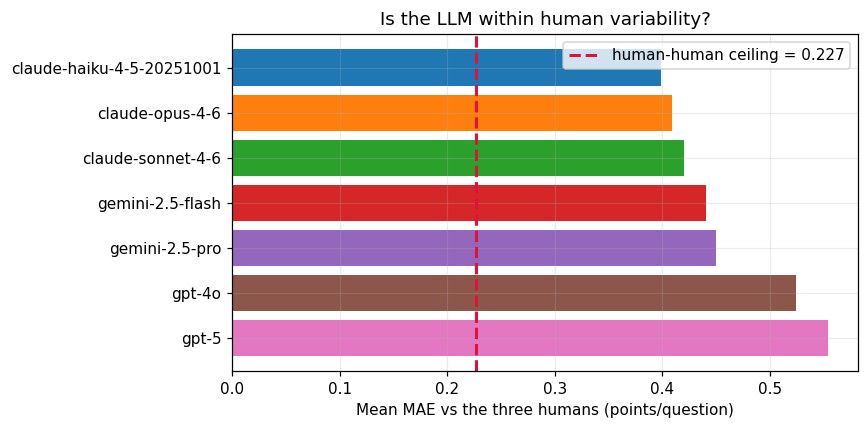

In [12]:
rows=[]
for m in MODELS:
    pred = llm_wide[m].reindex(hum_wide.index)
    d = {f"MAE_vs_{h}": np.abs(pred-hum_wide[h]).mean() for h in ["H1","H2","H3"]}
    d["MAE_vs_human_mean"] = np.mean(list(d.values()))
    d["model"]=m; rows.append(d)
lh = pd.DataFrame(rows).set_index("model").sort_values("MAE_vs_human_mean")
lh["human_ceiling(mean HH MAE)"] = mean_hh_mae
lh["within_human?"] = np.where(lh["MAE_vs_human_mean"]<=mean_hh_mae, "YES", "no")
display(lh.style.format({c:"{:.3f}" for c in lh.columns if c!="within_human?"}))

# visual
fig,ax = plt.subplots(figsize=(8,4))
order = lh.index
ax.barh(order, lh["MAE_vs_human_mean"], color=[MODEL_COLORS[m] for m in order])
ax.axvline(mean_hh_mae, color="crimson", ls="--", lw=2, label=f"human-human ceiling = {mean_hh_mae:.3f}")
ax.set_xlabel("Mean MAE vs the three humans (points/question)")
ax.set_title("Is the LLM within human variability?"); ax.legend()
ax.invert_yaxis(); plt.tight_layout(); plt.show()

## 7. Per-question analysis — where do models succeed or fail?

For each of the 5 questions (pooled over 5 students) we compare **human spread** (mean grader SD) against **LLM error** (mean |LLM − consensus|), and classify:

* **Easy** — humans agree *and* LLMs agree.
* **Hard** — humans disagree *and* LLMs struggle (shared difficulty — forgivable).
* **Interesting failure** — humans agree but LLMs miss badly (worth a qualitative look).

,human_disagreement,llm_mean_abs_err,llm_score_var,consensus_mean,class
question,,,,,
1,0.173,0.397,0.409,1.800,easy
2,0.215,0.574,0.440,1.767,hard (shared)
3,0.173,0.351,0.260,1.767,easy
4,0.115,0.444,0.402,1.900,INTERESTING failure
5,0.273,0.379,0.554,1.500,"humans split, LLM confident"


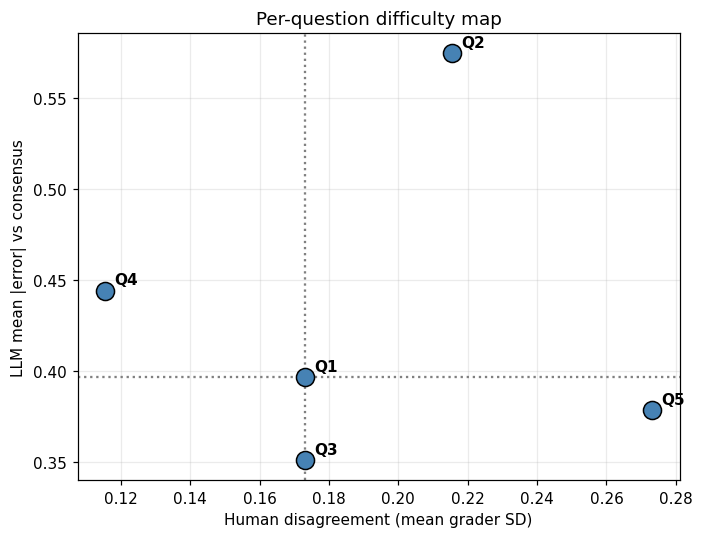

In [13]:
per_q = []
for q in QS:
    idx = [(p,q) for p in df["pdf_id"].unique()]
    hstd = hum_wide.loc[idx, ["H1","H2","H3"]].std(1, ddof=1).mean()
    cons = CONSENSUS.loc[idx]
    llm_err = np.abs(llm_wide.loc[idx, MODELS].sub(cons, axis=0)).mean().mean()
    llm_var = llm_wide.loc[idx, MODELS].values.std(ddof=1)
    per_q.append(dict(question=q, human_disagreement=hstd,
                      llm_mean_abs_err=llm_err, llm_score_var=llm_var,
                      consensus_mean=cons.mean()))
per_q = pd.DataFrame(per_q).set_index("question")

h_med = per_q["human_disagreement"].median(); e_med = per_q["llm_mean_abs_err"].median()
def classify(r):
    hi_h = r["human_disagreement"] > h_med; hi_e = r["llm_mean_abs_err"] > e_med
    if not hi_h and not hi_e: return "easy"
    if hi_h and hi_e: return "hard (shared)"
    if not hi_h and hi_e: return "INTERESTING failure"
    return "humans split, LLM confident"
per_q["class"] = per_q.apply(classify, axis=1)
display(per_q.style.format({c:"{:.3f}" for c in per_q.columns if c!="class"}))

fig,ax=plt.subplots(figsize=(6.5,5))
ax.scatter(per_q["human_disagreement"], per_q["llm_mean_abs_err"], s=140,
           c="steelblue", edgecolor="k", zorder=3)
for q,r in per_q.iterrows():
    ax.annotate(f"Q{q}", (r["human_disagreement"], r["llm_mean_abs_err"]),
                xytext=(6,4), textcoords="offset points", fontweight="bold")
ax.axvline(h_med, color="grey", ls=":"); ax.axhline(e_med, color="grey", ls=":")
ax.set_xlabel("Human disagreement (mean grader SD)")
ax.set_ylabel("LLM mean |error| vs consensus")
ax.set_title("Per-question difficulty map")
plt.tight_layout(); plt.show()

## 8. Run-to-run LLM self-consistency *(added analysis)*

Humans give one grade; each LLM graded **three times**. A model can be accurate *on average* yet erratic run-to-run. For every *(student, question)* we take the SD of a model's three run scores and average it — this is grading **noise** (a reliability property humans can't be measured on here, but which matters for deployment).

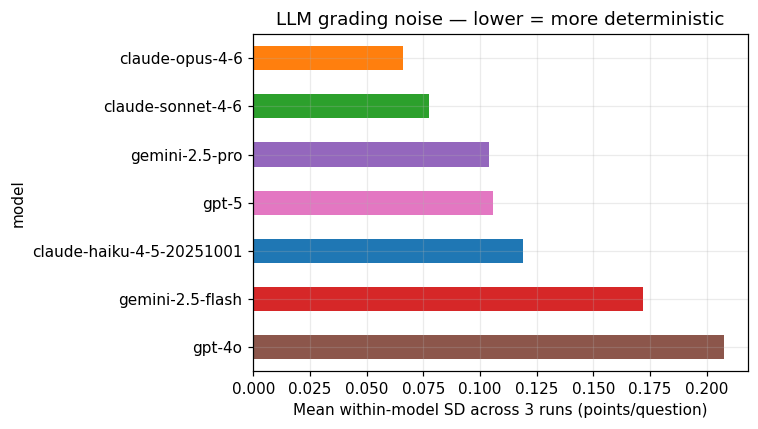

,run_to_run_SD
model,
claude-opus-4-6,0.066
claude-sonnet-4-6,0.078
gemini-2.5-pro,0.104
gpt-5,0.106
claude-haiku-4-5-20251001,0.119
gemini-2.5-flash,0.172
gpt-4o,0.208


Models near 0 are effectively deterministic graders; higher values mean the same answer can get a different mark on a re-run.


In [14]:
run_sd = (llm_long.groupby(["pdf_id","question","model"])["score"]
          .std(ddof=1).groupby("model").mean().sort_values())
fig,ax=plt.subplots(figsize=(7,4))
run_sd.plot.barh(ax=ax, color=[MODEL_COLORS[m] for m in run_sd.index])
ax.set_xlabel("Mean within-model SD across 3 runs (points/question)")
ax.set_title("LLM grading noise — lower = more deterministic")
ax.invert_yaxis(); plt.tight_layout(); plt.show()
display(run_sd.to_frame("run_to_run_SD"))
print("Models near 0 are effectively deterministic graders; higher values mean the same answer can get a different mark on a re-run.")

## 9. Statistical significance between models

Lower average MAE isn't enough — the difference could be noise. We compare each pair of models with a **Wilcoxon signed-rank test** on their per-instance absolute errors (paired over the 25 instances; non-parametric, no normality assumption). The heatmap shows which model (row) is *significantly more accurate* than another (column) at p < 0.05.

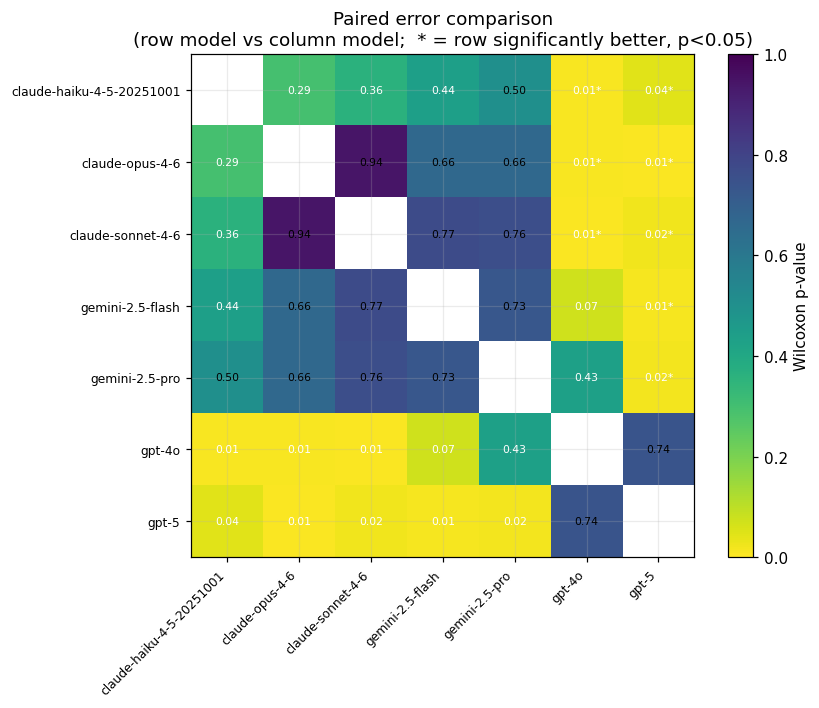

With only 25 paired points most differences are NOT significant — treat close MAE gaps as ties.


In [15]:
abs_err = pd.DataFrame({m: np.abs(llm_wide[m].reindex(CONSENSUS.index)-CONSENSUS).values
                        for m in MODELS}, index=CONSENSUS.index)
pmat = pd.DataFrame(np.nan, index=MODELS, columns=MODELS)
better = pd.DataFrame("", index=MODELS, columns=MODELS)
for a,b in itertools.permutations(MODELS,2):
    ea, eb = abs_err[a], abs_err[b]
    if (ea-eb).abs().sum()==0:
        p=1.0
    else:
        p = stats.wilcoxon(ea, eb, zero_method="wilcox")[1]
    pmat.loc[a,b]=p
    if p<0.05 and ea.mean()<eb.mean(): better.loc[a,b]="A<B*"

fig,ax=plt.subplots(figsize=(8,6.5))
im=ax.imshow(pmat.values, cmap="viridis_r", vmin=0, vmax=1)
ax.set_xticks(range(len(MODELS))); ax.set_xticklabels(MODELS, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(MODELS))); ax.set_yticklabels(MODELS, fontsize=8)
for i,a in enumerate(MODELS):
    for j,b in enumerate(MODELS):
        if i!=j:
            p=pmat.loc[a,b]; star="*" if p<0.05 and abs_err[a].mean()<abs_err[b].mean() else ""
            ax.text(j,i,f"{p:.2f}{star}",ha="center",va="center",
                    color="white" if p<.5 else "black", fontsize=7)
plt.colorbar(im,label="Wilcoxon p-value"); ax.set_title("Paired error comparison\n(row model vs column model;  * = row significantly better, p<0.05)")
plt.tight_layout(); plt.show()
print("With only 25 paired points most differences are NOT significant — treat close MAE gaps as ties.")

## 10. Visualizations

### 10a. Consensus vs. LLM scatter (agreement per model)

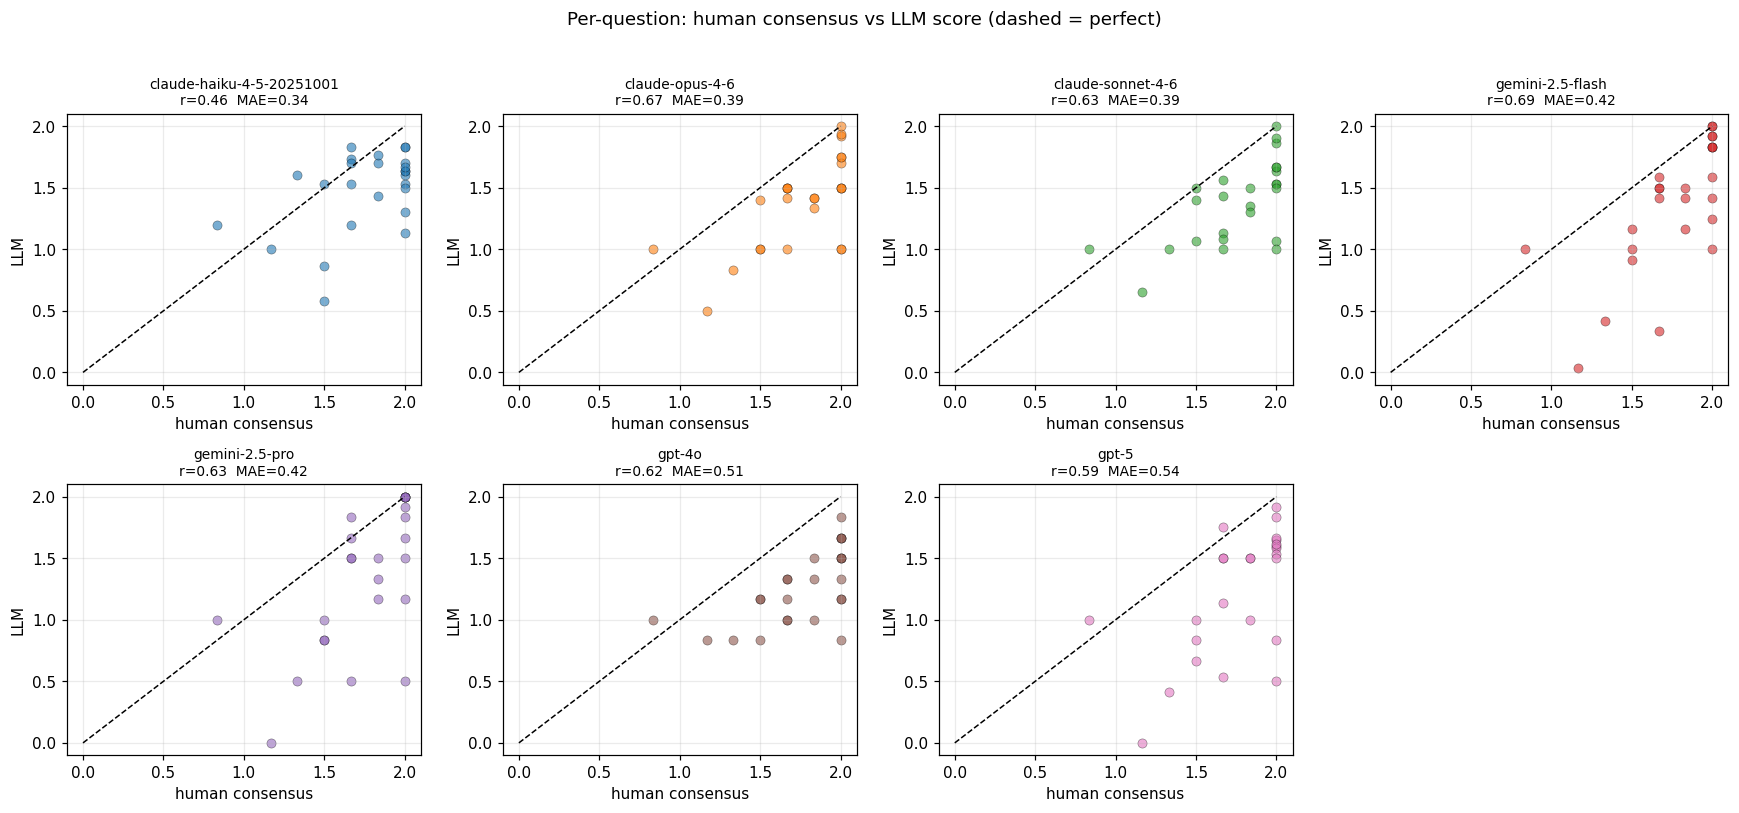

In [16]:
ncol=4; nrow=int(np.ceil(len(MODELS)/ncol))
fig,axes=plt.subplots(nrow,ncol,figsize=(4*ncol,3.6*nrow))
for ax,m in zip(axes.ravel(), MODELS):
    x=CONSENSUS.values; y=llm_wide[m].reindex(CONSENSUS.index).values
    ax.scatter(x,y,alpha=.6,color=MODEL_COLORS[m],edgecolor="k",lw=.3)
    ax.plot([0,2],[0,2],"k--",lw=1)
    r=stats.pearsonr(x,y)[0]; mae=np.abs(x-y).mean()
    ax.set_title(f"{m}\nr={r:.2f}  MAE={mae:.2f}",fontsize=9)
    ax.set_xlim(-.1,2.1); ax.set_ylim(-.1,2.1)
    ax.set_xlabel("human consensus"); ax.set_ylabel("LLM")
for ax in axes.ravel()[len(MODELS):]: ax.axis("off")
plt.suptitle("Per-question: human consensus vs LLM score (dashed = perfect)", y=1.02)
plt.tight_layout(); plt.show()

### 10b. Bland–Altman agreement (mean vs difference)

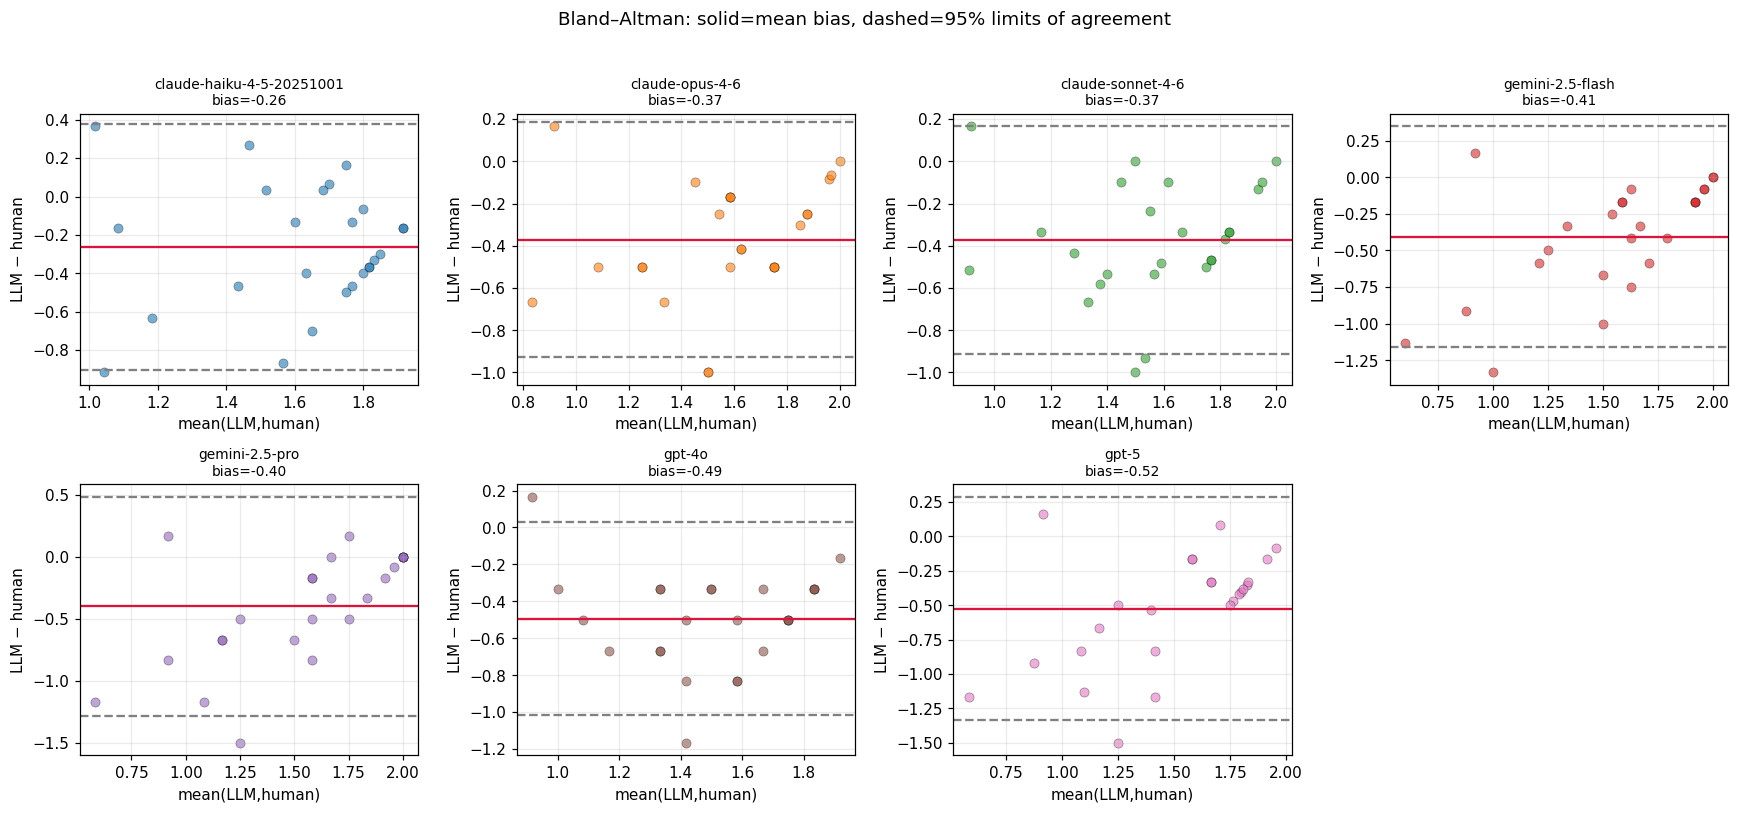

In [17]:
fig,axes=plt.subplots(nrow,ncol,figsize=(4*ncol,3.6*nrow))
for ax,m in zip(axes.ravel(), MODELS):
    x=CONSENSUS.values; y=llm_wide[m].reindex(CONSENSUS.index).values
    mean=(x+y)/2; diff=y-x
    md_=diff.mean(); sd_=diff.std(ddof=1)
    ax.scatter(mean,diff,alpha=.6,color=MODEL_COLORS[m],edgecolor="k",lw=.3)
    ax.axhline(md_,color="crimson"); ax.axhline(md_+1.96*sd_,color="grey",ls="--"); ax.axhline(md_-1.96*sd_,color="grey",ls="--")
    ax.set_title(f"{m}\nbias={md_:.2f}",fontsize=9)
    ax.set_xlabel("mean(LLM,human)"); ax.set_ylabel("LLM − human")
for ax in axes.ravel()[len(MODELS):]: ax.axis("off")
plt.suptitle("Bland–Altman: solid=mean bias, dashed=95% limits of agreement", y=1.02)
plt.tight_layout(); plt.show()

### 10c. Error boxplots & violins by model

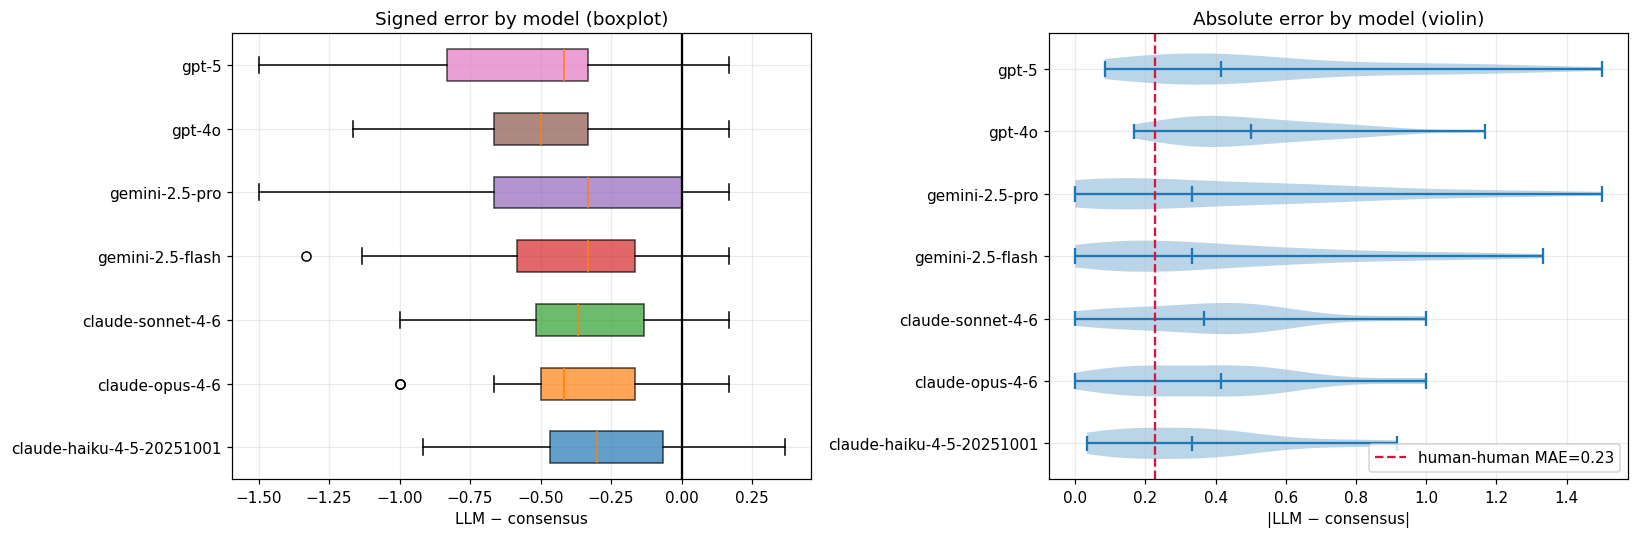

In [18]:
err_long=[]
for m in MODELS:
    e = (llm_wide[m].reindex(CONSENSUS.index)-CONSENSUS).values
    for v in e: err_long.append(dict(model=m, error=v))
err_long=pd.DataFrame(err_long)
order = llm_metrics.index.tolist()
fig,axes=plt.subplots(1,2,figsize=(15,5))
data=[err_long[err_long.model==m]["error"].values for m in order]
bp=axes[0].boxplot(data, vert=False, labels=order, patch_artist=True)
for patch,m in zip(bp["boxes"], order): patch.set_facecolor(MODEL_COLORS[m]); patch.set_alpha(.7)
axes[0].axvline(0,color="k"); axes[0].set_title("Signed error by model (boxplot)"); axes[0].set_xlabel("LLM − consensus")
vp=axes[1].violinplot([np.abs(d) for d in data], vert=False, showmedians=True)
axes[1].set_yticks(range(1,len(order)+1)); axes[1].set_yticklabels(order)
axes[1].axvline(mean_hh_mae,color="crimson",ls="--",label=f"human-human MAE={mean_hh_mae:.2f}")
axes[1].set_title("Absolute error by model (violin)"); axes[1].set_xlabel("|LLM − consensus|"); axes[1].legend()
plt.tight_layout(); plt.show()

### 10d. Absolute-error heatmap (question instance × model)

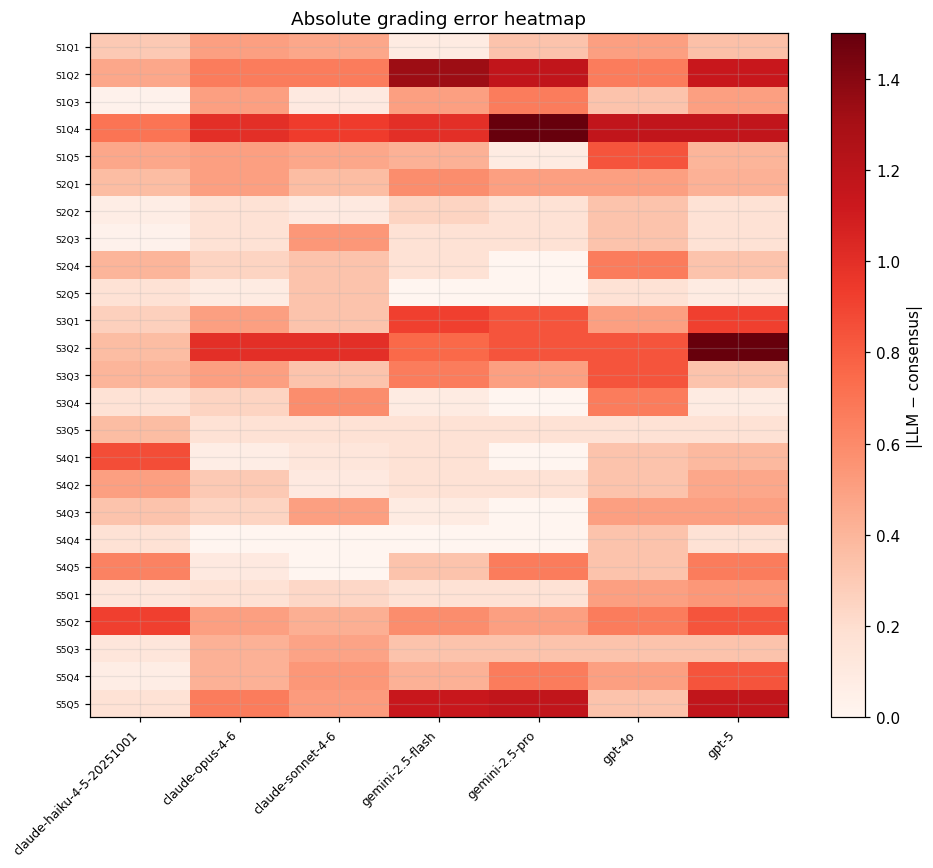

In [19]:
H = abs_err.copy()
H.index = [f"S{p}Q{q}" for p,q in H.index]
fig,ax=plt.subplots(figsize=(9, 8))
im=ax.imshow(H.values, aspect="auto", cmap="Reds", vmin=0)
ax.set_xticks(range(len(MODELS))); ax.set_xticklabels(MODELS, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(H))); ax.set_yticklabels(H.index, fontsize=6)
plt.colorbar(im,label="|LLM − consensus|")
ax.set_title("Absolute grading error heatmap"); plt.tight_layout(); plt.show()

### 10e. Correlation matrix — all graders + all LLMs

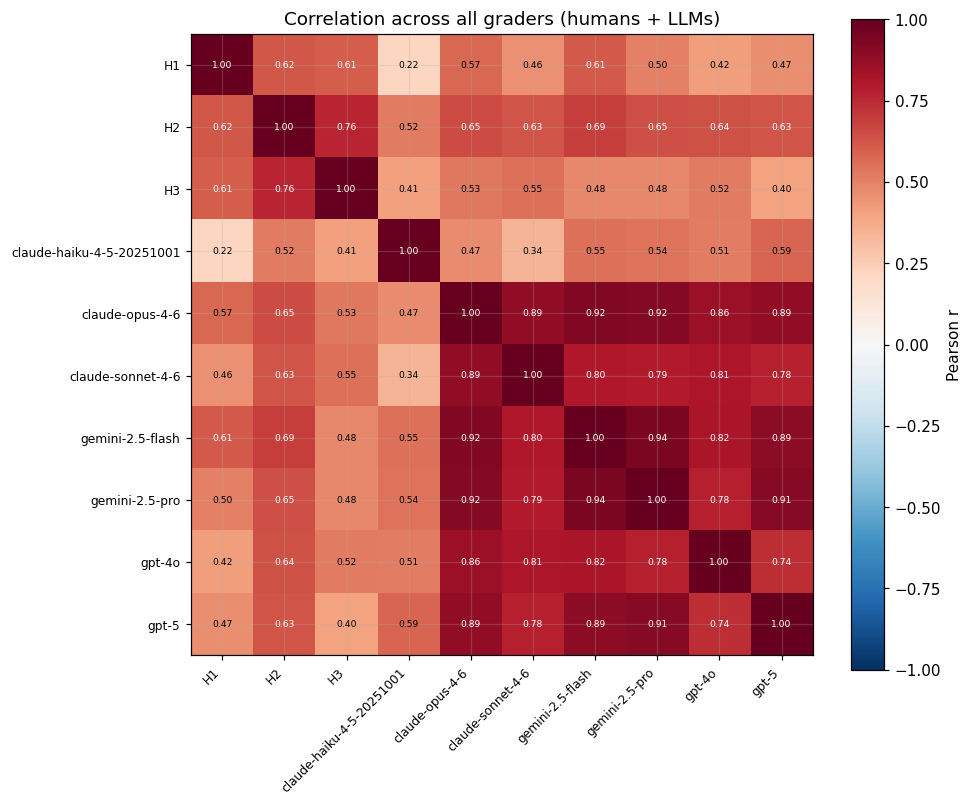

In [20]:
allw = hum_wide[["H1","H2","H3"]].join(llm_wide[MODELS])
corr = allw.corr()
fig,ax=plt.subplots(figsize=(9,7.5))
im=ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j,i,f"{corr.values[i,j]:.2f}",ha="center",va="center",fontsize=6,
                color="white" if abs(corr.values[i,j])>.6 else "black")
plt.colorbar(im,label="Pearson r"); ax.set_title("Correlation across all graders (humans + LLMs)")
plt.tight_layout(); plt.show()

### 10f. Distribution of grading bias  &  10g. Radar of normalized metrics

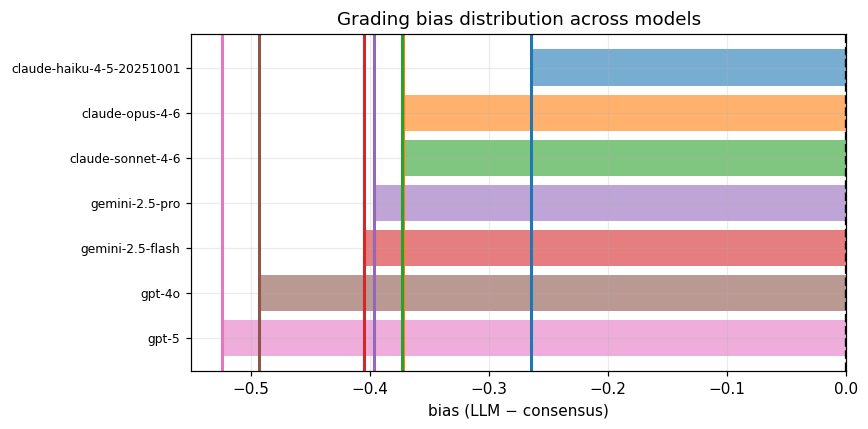

In [21]:
fig,ax=plt.subplots(figsize=(8,4))
for m in MODELS:
    e=(llm_wide[m].reindex(CONSENSUS.index)-CONSENSUS).values
    ax.axvline(e.mean(),color=MODEL_COLORS[m],lw=2)
ax.axvline(0,color="k",ls="--")
biases = llm_metrics["Bias"].sort_values()
ax.barh(range(len(biases)), biases.values, color=[MODEL_COLORS[m] for m in biases.index], alpha=.6)
ax.set_yticks(range(len(biases))); ax.set_yticklabels(biases.index, fontsize=8)
ax.set_xlabel("bias (LLM − consensus)"); ax.set_title("Grading bias distribution across models")
plt.tight_layout(); plt.show()

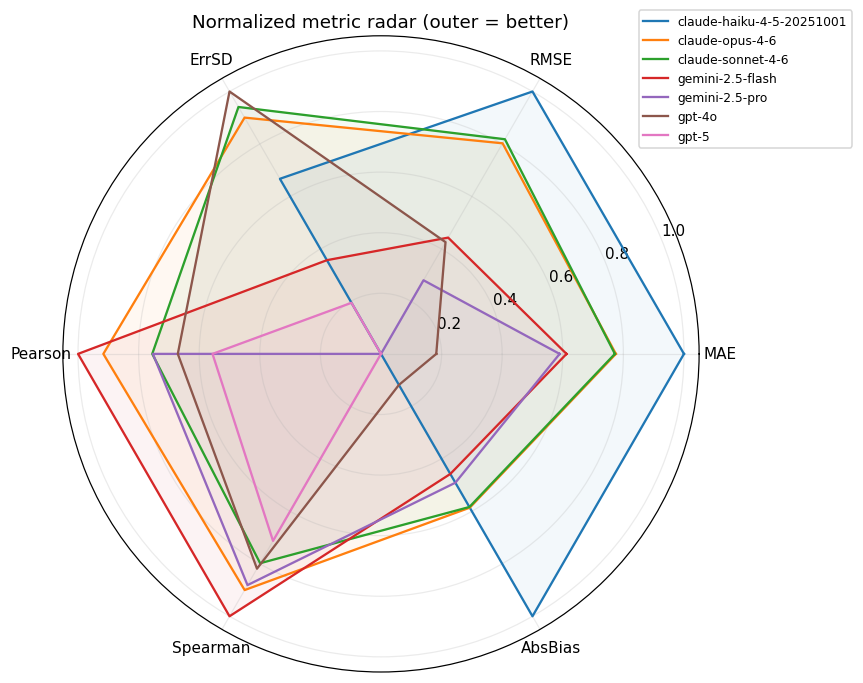

In [22]:
# Radar: normalize metrics to [0,1] where 1 = best
radar_metrics = ["MAE","RMSE","ErrSD","Pearson","Spearman","AbsBias"]
R = llm_metrics.copy(); R["AbsBias"]=R["Bias"].abs()
norm = pd.DataFrame(index=R.index)
for met in radar_metrics:
    v=R[met]
    if met in ["Pearson","Spearman"]:      # higher better
        norm[met]=(v-v.min())/(v.max()-v.min()+1e-9)
    else:                                   # lower better
        norm[met]=1-(v-v.min())/(v.max()-v.min()+1e-9)
ang=np.linspace(0,2*np.pi,len(radar_metrics),endpoint=False); ang=np.r_[ang,ang[:1]]
fig,ax=plt.subplots(figsize=(8,8),subplot_kw=dict(polar=True))
for m in MODELS:
    vals=norm.loc[m,radar_metrics].values; vals=np.r_[vals,vals[:1]]
    ax.plot(ang,vals,label=m,color=MODEL_COLORS[m]); ax.fill(ang,vals,alpha=.05,color=MODEL_COLORS[m])
ax.set_xticks(ang[:-1]); ax.set_xticklabels(radar_metrics)
ax.set_title("Normalized metric radar (outer = better)"); ax.legend(bbox_to_anchor=(1.25,1.05), fontsize=8)
plt.tight_layout(); plt.show()

## 11. Overall ranking & composite score

We rank models on the metrics that matter, then form a transparent **composite** (equal-weighted average of normalized metrics — the same normalization as the radar, so 1 = best on every axis). The composite is a convenience; the underlying columns are what to trust.

,COMPOSITE,MAE,RMSE,Pearson,Spearman,ICC_as_4th,Bias,ErrSD,run_SD,MAE_vs_humans
claude-opus-4-6,0.859,0.385,0.465,0.671,0.686,0.425,-0.372,0.284,0.066,0.409
claude-sonnet-4-6,0.796,0.386,0.461,0.635,0.648,0.408,-0.373,0.277,0.078,0.420
gemini-2.5-flash,0.640,0.419,0.554,0.690,0.722,0.426,-0.405,0.385,0.172,0.441
claude-haiku-4-5-20251001,0.618,0.339,0.416,0.464,0.357,0.397,-0.265,0.327,0.119,0.399
gemini-2.5-pro,0.562,0.423,0.594,0.634,0.679,0.407,-0.397,0.451,0.104,0.450
gpt-4o,0.402,0.507,0.558,0.616,0.656,0.342,-0.493,0.266,0.208,0.524
gpt-5,0.280,0.544,0.663,0.590,0.617,0.347,-0.524,0.415,0.106,0.554


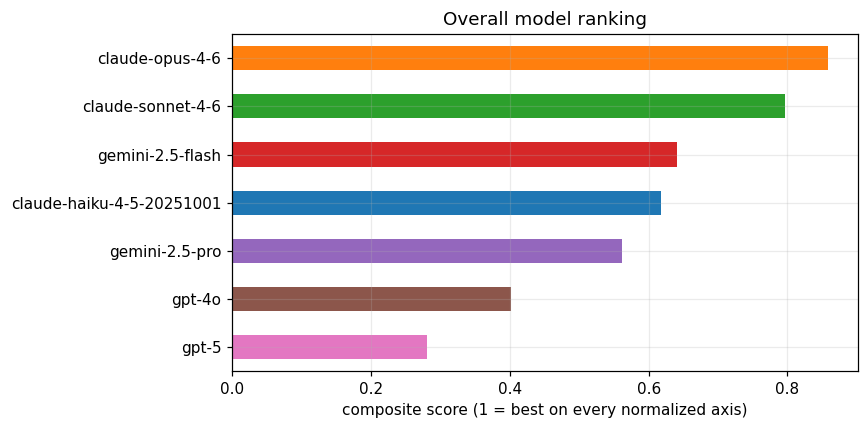

In [23]:
rank = llm_metrics.copy()
rank["AbsBias"]=rank["Bias"].abs()
rank["run_SD"]=run_sd.reindex(rank.index)
rank["MAE_vs_humans"]=lh["MAE_vs_human_mean"].reindex(rank.index)
rank["ICC_as_4th"]=icc_panel["ICC21_with_LLM"].reindex(rank.index)

comp_metrics = {"MAE":False,"RMSE":False,"ErrSD":False,"AbsBias":False,"run_SD":False,
                "Pearson":True,"Spearman":True,"ICC_as_4th":True}
comp = pd.DataFrame(index=rank.index)
for met,higher in comp_metrics.items():
    v=rank[met].astype(float); rng=v.max()-v.min()+1e-9
    comp[met]=(v-v.min())/rng if higher else 1-(v-v.min())/rng
rank["COMPOSITE"]=comp.mean(1)
rank=rank.sort_values("COMPOSITE", ascending=False)

show_cols=["COMPOSITE","MAE","RMSE","Pearson","Spearman","ICC_as_4th","Bias","ErrSD","run_SD","MAE_vs_humans"]
display(rank[show_cols].style.format("{:.3f}")
        .background_gradient(subset=["COMPOSITE"], cmap="Blues")
        .background_gradient(subset=["MAE","RMSE","ErrSD","run_SD"], cmap="Reds")
        .background_gradient(subset=["Pearson","Spearman","ICC_as_4th"], cmap="Greens"))

fig,ax=plt.subplots(figsize=(8,4))
rank["COMPOSITE"].sort_values().plot.barh(ax=ax, color=[MODEL_COLORS[m] for m in rank["COMPOSITE"].sort_values().index])
ax.set_xlabel("composite score (1 = best on every normalized axis)")
ax.set_title("Overall model ranking"); plt.tight_layout(); plt.show()

## 12. Executive summary

The cell below auto-generates the take-aways from the numbers above so the narrative always matches the data.

In [24]:
best = rank.index[0]
print("="*70)
print("EXECUTIVE SUMMARY — Multi-LLM vs Multi-Human grading (Biomaterials)")
print("="*70)
print(f"Human ceiling: ICC(2,1)={icc21_h:.2f}, Krippendorff a={alpha_h:.2f}, "
      f"mean human-human MAE={mean_hh_mae:.2f} pts/question.")
print(f"  -> Humans themselves are {'highly' if icc21_h>0.75 else 'moderately' if icc21_h>0.5 else 'weakly'} consistent; "
      f"this is the realistic bar for any LLM.")
print()
print(f"Best overall model by composite: {best}")
print(f"   MAE vs consensus = {rank.loc[best,'MAE']:.2f} | vs humans = {rank.loc[best,'MAE_vs_humans']:.2f} "
      f"(human ceiling {mean_hh_mae:.2f})")
print(f"   ICC as 4th grader = {rank.loc[best,'ICC_as_4th']:.2f} (human-only {icc21_h:.2f})")
within = lh.index[lh['MAE_vs_human_mean']<=mean_hh_mae].tolist()
print()
print(f"Models effectively WITHIN human variability (MAE vs humans <= human-human MAE): "
      f"{within if within else 'none — all disagree with humans more than humans disagree among themselves'}")
print()
harsh = (llm_metrics['Bias']<0).sum()
print(f"Systematic bias: {harsh}/{len(MODELS)} models grade HARSHER than the human consensus "
      f"(mean bias {llm_metrics['Bias'].mean():+.2f} pts/question).")
print(f"   -> The dominant error is a global harshness offset, not random noise; a per-rubric "
      f"calibration constant would close much of the gap.")
interesting = per_q.index[per_q['class']=='INTERESTING failure'].tolist()
print()
print(f"Questions where humans agreed but LLMs missed (investigate qualitatively): "
      f"{['Q%d'%q for q in interesting] if interesting else 'none'}")
print("="*70)

EXECUTIVE SUMMARY — Multi-LLM vs Multi-Human grading (Biomaterials)
Human ceiling: ICC(2,1)=0.50, Krippendorff a=0.47, mean human-human MAE=0.23 pts/question.
  -> Humans themselves are moderately consistent; this is the realistic bar for any LLM.

Best overall model by composite: claude-opus-4-6
   MAE vs consensus = 0.39 | vs humans = 0.41 (human ceiling 0.23)
   ICC as 4th grader = 0.43 (human-only 0.50)

Models effectively WITHIN human variability (MAE vs humans <= human-human MAE): none — all disagree with humans more than humans disagree among themselves

Systematic bias: 7/7 models grade HARSHER than the human consensus (mean bias -0.40 pts/question).
   -> The dominant error is a global harshness offset, not random noise; a per-rubric calibration constant would close much of the gap.

Questions where humans agreed but LLMs missed (investigate qualitatively): ['Q4']
